# Tesla Stock Price Prediction using SimpleRNN & LSTM
### Deep Learning Time-Series Project | Financial Domain

**Author:** Bhargav


**Dataset:** TSLA.csv — Tesla Historical Stock Prices (2018–2024)  
**Objective:** Build and compare SimpleRNN and LSTM models to predict Tesla's closing stock price for 1-day, 5-day, and 10-day horizons.

---


## 1. Imports & Setup

In [1]:
# I'll start by importing all the libraries I need for this project.
# These cover data manipulation, visualization, preprocessing, and deep learning.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# For hyperparameter tuning
from sklearn.model_selection import ParameterGrid

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Style settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Set2')

print("✅ All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")


✅ All libraries imported successfully!
TensorFlow version: 2.20.0
NumPy version: 2.0.2
Pandas version: 2.2.2


## 2. Load & Explore Dataset

In [4]:
from google.colab import files

print("Please upload the 'TSLA.csv' file:")
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

Please upload the 'TSLA.csv' file:


Saving TSLA.csv to TSLA (1).csv
User uploaded file "TSLA (1).csv" with length 175082 bytes


In [6]:
# I'll load the TSLA dataset and take my first look at its structure.
# Since the project says to use the closing price, I'll keep that in focus throughout.

df = pd.read_csv('TSLA.csv', parse_dates=['Date'])
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)

print("=" * 55)
print("📊  TESLA STOCK PRICE DATASET — OVERVIEW")
print("=" * 55)
print(f"Shape         : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Date Range    : {df.index.min().date()}  →  {df.index.max().date()}")
print(f"\nColumn names  : {list(df.columns)}")
print("\nFirst 5 rows:")
df.head()


📊  TESLA STOCK PRICE DATASET — OVERVIEW
Shape         : 1827 rows × 6 columns
Date Range    : 2018-01-01  →  2024-12-31

Column names  : ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

First 5 rows:


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2018-01-01,20.252155,20.678047,20.222615,20.274357,20.182621,61986409
2018-01-02,20.031401,20.466407,20.074095,20.230633,20.149758,146489140
2018-01-03,20.575073,20.918999,20.237541,20.584512,20.524144,64663163
2018-01-04,21.474189,21.534941,21.378927,21.395042,21.310126,101621625
2018-01-05,21.280332,21.427845,21.092460,21.297613,21.284468,50440897


In [7]:
# Let me check the data types and look at summary statistics
print("Data Types:")
print(df.dtypes)
print("\nBasic Statistics:")
df.describe().round(2)


Data Types:
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object

Basic Statistics:


,Open,High,Low,Close,Adj Close,Volume
count,1827.00,1827.00,1827.00,1827.00,1827.00,1.827000e+03
mean,203.37,205.94,201.81,203.91,203.38,1.158322e+08
std,209.89,212.57,208.25,210.45,209.90,4.880301e+07
min,15.57,15.85,15.60,15.65,15.60,3.000898e+07
25%,35.55,35.97,35.18,35.55,35.48,7.459792e+07
50%,138.76,140.71,138.20,139.49,139.21,1.157346e+08
75%,281.99,285.29,279.26,283.21,282.17,1.585569e+08
max,926.70,932.30,913.52,926.03,921.49,1.997406e+08


## 3. Data Cleaning & Missing Value Analysis

In [8]:
# One of the most important steps — checking for missing values.
# For time-series stock data, handling missing values requires special care
# because we can't just use a simple mean/median fill; we need to preserve temporal order.

print("=" * 45)
print("🔍  MISSING VALUE ANALYSIS")
print("=" * 45)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct.round(2)})
print(missing_df)

print(f"\nTotal missing values: {df.isnull().sum().sum()}")


🔍  MISSING VALUE ANALYSIS
           Missing Count  Missing %
Open                   0        0.0
High                   0        0.0
Low                    0        0.0
Close                  0        0.0
Adj Close              0        0.0
Volume                 0        0.0

Total missing values: 0


In [9]:
# I'll handle missing values using forward fill (ffill) — this is the
# correct approach for time-series financial data because it uses the
# last known price, which is how markets actually behave on non-trading days.
# Using mean/median would introduce data leakage from future values.

df.ffill(inplace=True)   # Forward fill first
df.bfill(inplace=True)   # Backward fill for any at the very start

# Verify
print(f"Missing values after cleaning: {df.isnull().sum().sum()}")
print(f"\nDataset shape after cleaning: {df.shape}")
print("\n✅ Dataset is clean and ready for analysis!")


Missing values after cleaning: 0

Dataset shape after cleaning: (1827, 6)

✅ Dataset is clean and ready for analysis!


In [10]:
# Let me also check for duplicate dates
duplicates = df.index.duplicated().sum()
print(f"Duplicate date entries: {duplicates}")
if duplicates == 0:
    print("✅ No duplicate dates found.")


Duplicate date entries: 0
✅ No duplicate dates found.


## 4. Exploratory Data Analysis (EDA)

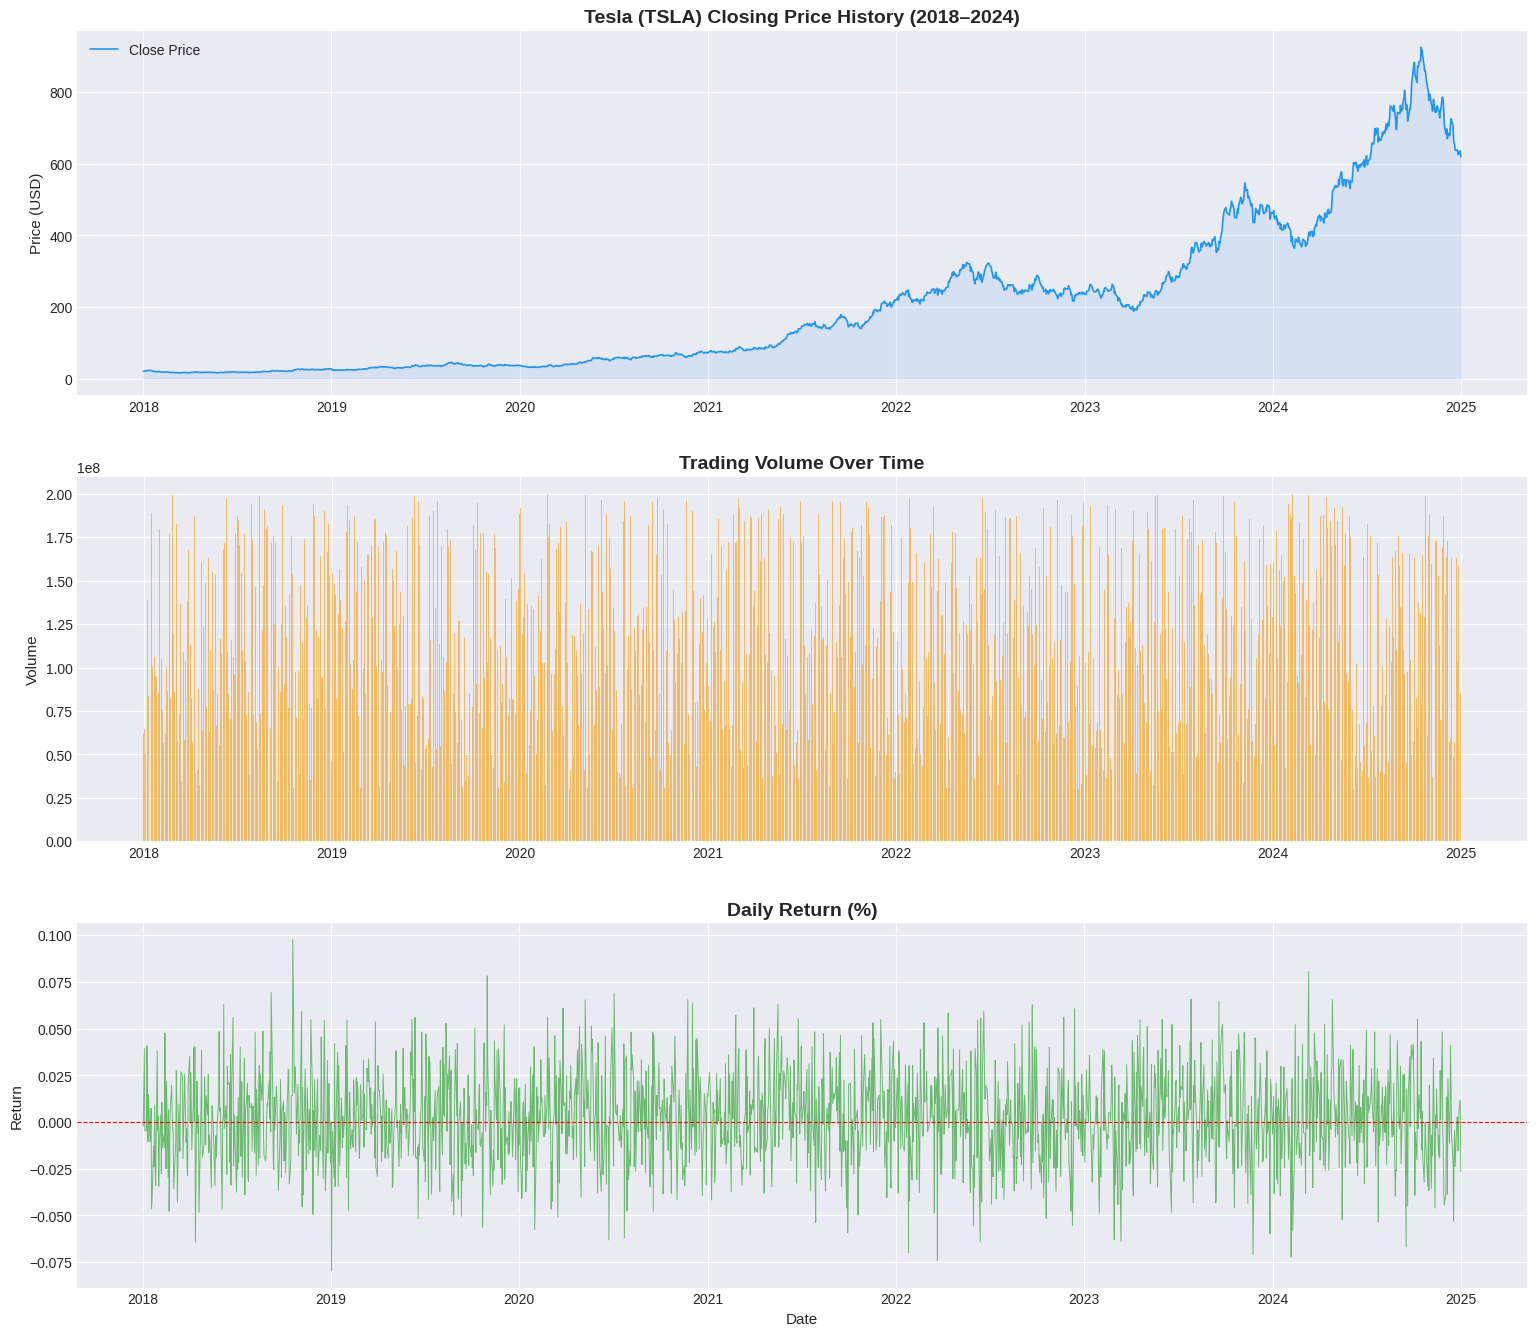

✅ Price overview chart saved.


In [11]:
# I'll start EDA with a full price history plot to understand the overall trend.

fig, axes = plt.subplots(3, 1, figsize=(16, 14))

# Plot 1: Full Closing Price History
axes[0].plot(df.index, df['Close'], color='#2196F3', linewidth=1.2, label='Close Price')
axes[0].fill_between(df.index, df['Close'], alpha=0.1, color='#2196F3')
axes[0].set_title('Tesla (TSLA) Closing Price History (2018–2024)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price (USD)', fontsize=11)
axes[0].legend()

# Plot 2: Volume
axes[1].bar(df.index, df['Volume'], color='#FF9800', alpha=0.6, width=1)
axes[1].set_title('Trading Volume Over Time', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Volume', fontsize=11)

# Plot 3: Daily Return
df['Daily_Return'] = df['Close'].pct_change()
axes[2].plot(df.index, df['Daily_Return'], color='#4CAF50', linewidth=0.7, alpha=0.8)
axes[2].axhline(0, color='red', linestyle='--', linewidth=0.8)
axes[2].set_title('Daily Return (%)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Return', fontsize=11)
axes[2].set_xlabel('Date', fontsize=11)

plt.tight_layout(pad=3)
plt.savefig('tsla_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Price overview chart saved.")


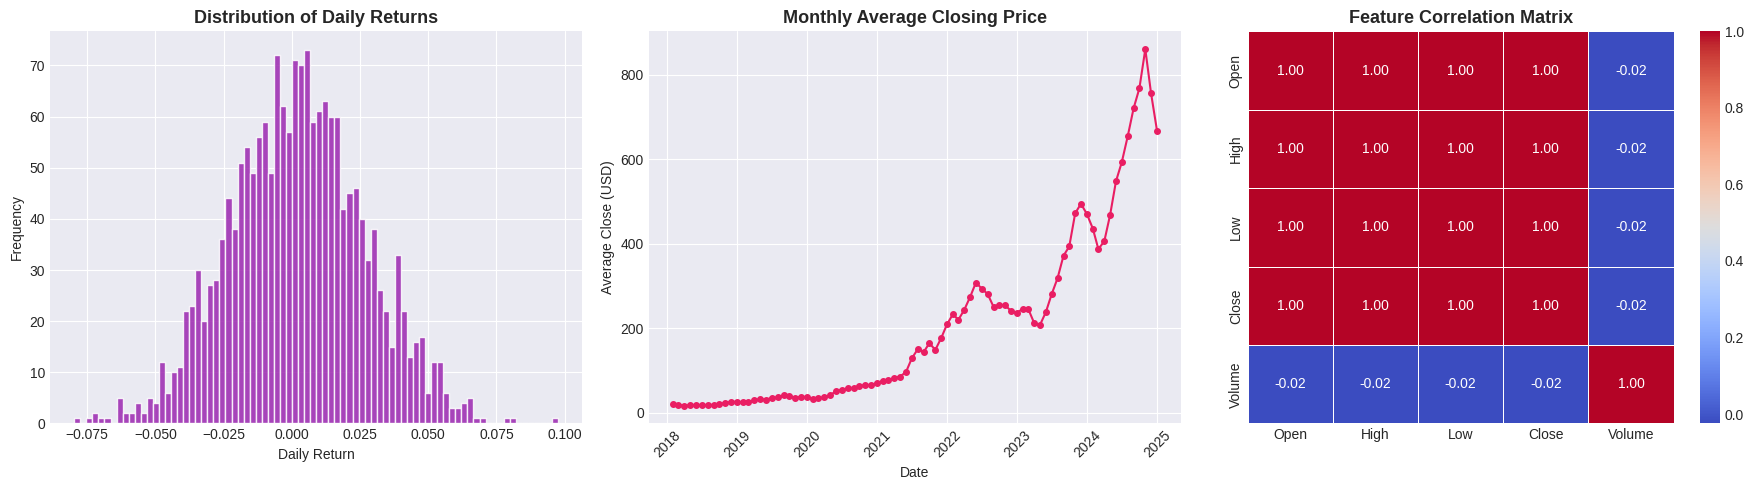

In [12]:
# Now let me look at the distribution of returns and statistical properties

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Return distribution
axes[0].hist(df['Daily_Return'].dropna(), bins=80, color='#9C27B0', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution of Daily Returns', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Daily Return')
axes[0].set_ylabel('Frequency')

# Monthly average closing price
monthly = df['Close'].resample('ME').mean()
axes[1].plot(monthly.index, monthly.values, marker='o', markersize=4, color='#E91E63', linewidth=1.5)
axes[1].set_title('Monthly Average Closing Price', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Average Close (USD)')
axes[1].tick_params(axis='x', rotation=45)

# Correlation heatmap
corr = df[['Open','High','Low','Close','Volume']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[2],
            linewidths=0.5, annot_kws={'size': 10})
axes[2].set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('tsla_eda.png', dpi=150, bbox_inches='tight')
plt.show()


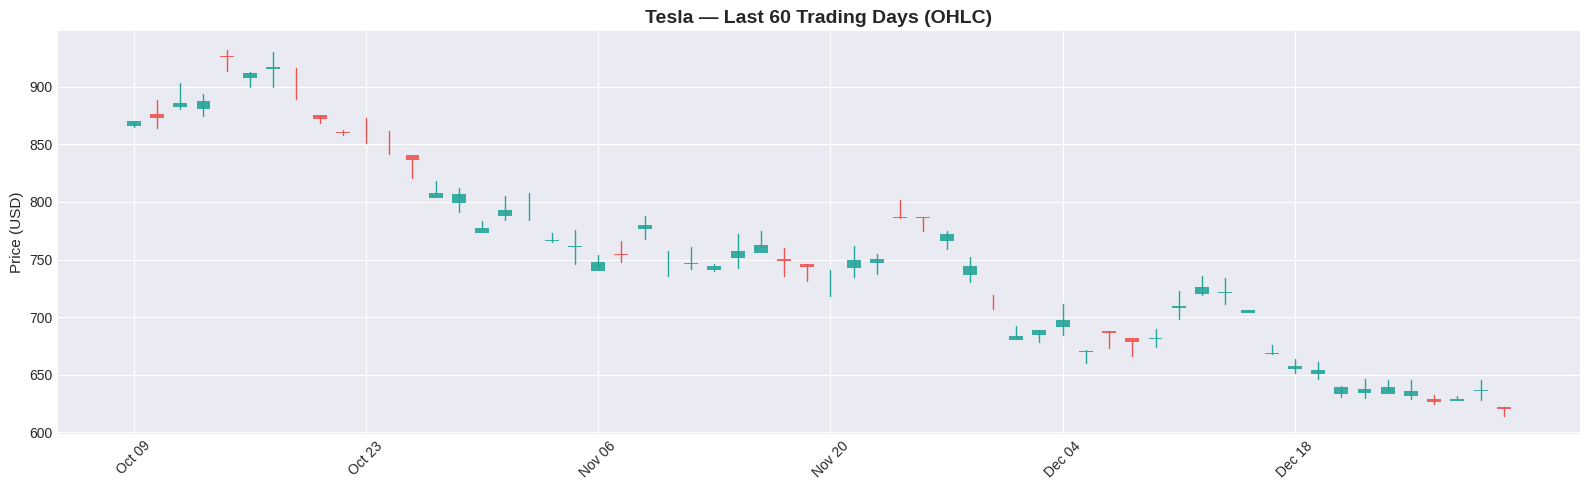

In [13]:
# Candlestick-style OHLC insight — Let me look at the last 60 trading days for detail

last_60 = df.tail(60).copy()

fig, ax = plt.subplots(figsize=(16, 5))
for i, (date, row) in enumerate(last_60.iterrows()):
    color = '#26a69a' if row['Close'] >= row['Open'] else '#ef5350'
    ax.plot([i, i], [row['Low'], row['High']], color=color, linewidth=1)
    ax.bar(i, abs(row['Close'] - row['Open']), bottom=min(row['Open'], row['Close']),
           color=color, width=0.6, alpha=0.9)

ax.set_title('Tesla — Last 60 Trading Days (OHLC)', fontsize=14, fontweight='bold')
ax.set_ylabel('Price (USD)', fontsize=11)
ax.set_xticks(range(0, 60, 10))
ax.set_xticklabels([last_60.index[i].strftime('%b %d') for i in range(0, 60, 10)], rotation=45)
plt.tight_layout()
plt.savefig('tsla_ohlc.png', dpi=150, bbox_inches='tight')
plt.show()


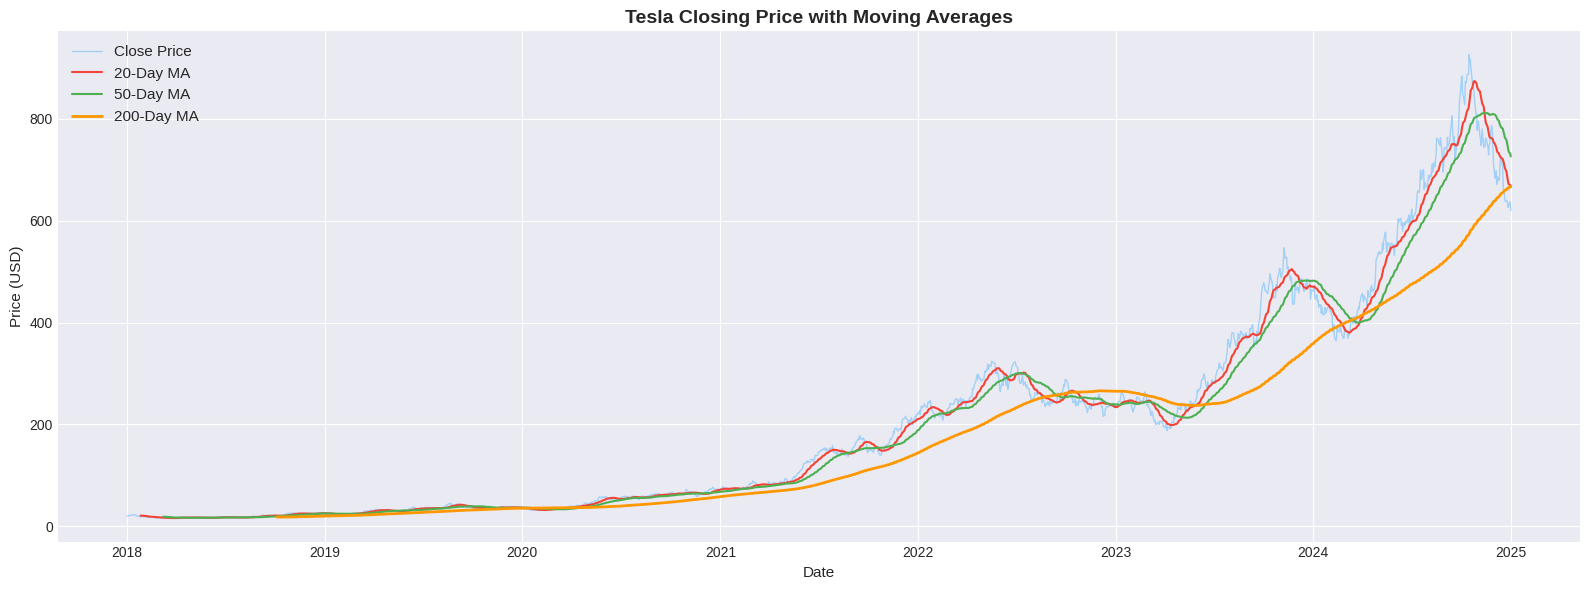

Key Stats:
  Mean Close   : $203.91
  Std Dev      : $210.45
  Max Close    : $926.03
  Min Close    : $15.65
  Avg Daily Ret: 0.2180%
  Volatility   : 2.4721%


In [14]:
# Rolling statistics — Moving averages are fundamental in stock analysis

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df.index, df['Close'], color='#90CAF9', linewidth=1, alpha=0.8, label='Close Price')
ax.plot(df.index, df['Close'].rolling(20).mean(), color='#F44336', linewidth=1.5, label='20-Day MA')
ax.plot(df.index, df['Close'].rolling(50).mean(), color='#4CAF50', linewidth=1.5, label='50-Day MA')
ax.plot(df.index, df['Close'].rolling(200).mean(), color='#FF9800', linewidth=2, label='200-Day MA')

ax.set_title('Tesla Closing Price with Moving Averages', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Price (USD)', fontsize=11)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('tsla_moving_avg.png', dpi=150, bbox_inches='tight')
plt.show()

print("Key Stats:")
print(f"  Mean Close   : ${df['Close'].mean():.2f}")
print(f"  Std Dev      : ${df['Close'].std():.2f}")
print(f"  Max Close    : ${df['Close'].max():.2f}")
print(f"  Min Close    : ${df['Close'].min():.2f}")
print(f"  Avg Daily Ret: {df['Daily_Return'].mean()*100:.4f}%")
print(f"  Volatility   : {df['Daily_Return'].std()*100:.4f}%")


## 5. Feature Engineering & Data Preprocessing

In [15]:
# I'll use the Adj Close column as the target as specified in the project brief.
# Then I'll scale the data using MinMaxScaler for better neural network convergence.

# Select Adj Close as target
data = df[['Adj Close']].copy()

print(f"Target column: 'Adj Close'")
print(f"Total data points: {len(data)}")

# Scale to [0, 1] range
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

print(f"\nScaled data range: [{scaled_data.min():.4f}, {scaled_data.max():.4f}]")
print("✅ MinMaxScaler applied successfully.")


Target column: 'Adj Close'
Total data points: 1827

Scaled data range: [0.0000, 1.0000]
✅ MinMaxScaler applied successfully.


In [18]:
# Create time-series sequences — this is the core transformation for LSTM/RNN.
# I'll use a sliding window of 60 days (past 60 trading days) to predict the next day.

def create_sequences(data, window_size=60):
    """
    Creates input (X) and output (y) sequences for time-series modelling.
    X: window of past `window_size` days
    y: next day's price
    """
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i - window_size:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

WINDOW_SIZE = 60

X, y = create_sequences(scaled_data, WINDOW_SIZE)
print(f"Sequence shape  →  X: {X.shape}  |  y: {y.shape}")
print(f"Window size: {WINDOW_SIZE} trading days (~3 months of look-back)")


Sequence shape  →  X: (1767, 60)  |  y: (1767,)
Window size: 60 trading days (~3 months of look-back)


In [19]:
# Train/Test split — I'll use 80% for training and 20% for testing.
# Important: I do NOT shuffle the data because time order must be preserved.

split = int(len(X) * 0.80)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Reshape for RNN/LSTM — needs (samples, timesteps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test  = X_test.reshape((X_test.shape[0],  X_test.shape[1],  1))

print("=" * 48)
print("  DATA SPLIT SUMMARY")
print("=" * 48)
print(f"  Total sequences   : {len(X)}")
print(f"  Training samples  : {X_train.shape[0]}  ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Test samples      : {X_test.shape[0]}   ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"  Input shape       : {X_train.shape}")
print(f"  Output shape      : {y_train.shape}")


  DATA SPLIT SUMMARY
  Total sequences   : 1767
  Training samples  : 1413  (80.0%)
  Test samples      : 354   (20.0%)
  Input shape       : (1413, 60, 1)
  Output shape      : (1413,)


## 6. Model Development

### 6.1 SimpleRNN Model

In [21]:
# I'll build the SimpleRNN model first. SimpleRNN is good for short-term dependencies
# but struggles with long sequences due to the vanishing gradient problem.
# I'll use two stacked RNN layers with Dropout for regularization.

def build_rnn(units=64, dropout=0.2, learning_rate=0.001):
    model = Sequential([
        SimpleRNN(units, return_sequences=True, input_shape=(WINDOW_SIZE, 1)),
        Dropout(dropout),
        SimpleRNN(units // 2, return_sequences=False),
        Dropout(dropout),
        Dense(32, activation='relu'),
        Dense(1)
    ], name='SimpleRNN_Model')

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='mean_squared_error',
        metrics=['mae']
    )
    return model

rnn_model = build_rnn()
rnn_model.summary()


Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 60, 64)         │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,417 (32.88 KB)

 Trainable params: 8,417 (32.88 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# Train the SimpleRNN model with EarlyStopping and ModelCheckpoint callbacks.
# EarlyStopping stops training when validation loss stops improving — prevents overfitting.

callbacks_rnn = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_rnn_model.keras', monitor='val_loss', save_best_only=True, verbose=0)
]

print("🚀 Training SimpleRNN model...")
history_rnn = rnn_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=callbacks_rnn,
    verbose=1
)
print("\n✅ SimpleRNN training complete!")


🚀 Training SimpleRNN model...
Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 0.0076 - mae: 0.0597 - val_loss: 0.0049 - val_mae: 0.0614
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.0018 - mae: 0.0275 - val_loss: 0.0020 - val_mae: 0.0339
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 9.8342e-04 - mae: 0.0189 - val_loss: 0.0019 - val_mae: 0.0341
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 7.9246e-04 - mae: 0.0177 - val_loss: 0.0021 - val_mae: 0.0336
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 7.6413e-04 - mae: 0.0172 - val_loss: 0.0019 - val_mae: 0.0332
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 6.1397e-04 - mae: 0.0159 - val_loss: 0.0014 - val_mae: 0.0287
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 4.8238e-04 - mae: 0.0139 - val_loss: 0.0019 - val_mae: 0.0349
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 5.5487e-04 - mae: 0.0145 - val_loss: 0.0012 - val_mae: 0.0262
Ep

### 6.2 LSTM Model

In [23]:
# Now I'll build the LSTM model. LSTM is an upgrade over SimpleRNN —
# it has memory cells and gating mechanisms (input, forget, output gates)
# that allow it to learn long-range dependencies much more effectively.

def build_lstm(units=64, dropout=0.2, learning_rate=0.001):
    model = Sequential([
        LSTM(units, return_sequences=True, input_shape=(WINDOW_SIZE, 1)),
        Dropout(dropout),
        LSTM(units // 2, return_sequences=False),
        Dropout(dropout),
        Dense(32, activation='relu'),
        Dense(1)
    ], name='LSTM_Model')

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='mean_squared_error',
        metrics=['mae']
    )
    return model

lstm_model = build_lstm()
lstm_model.summary()


Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,401 (118.75 KB)

 Trainable params: 30,401 (118.75 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
# Train the LSTM model

callbacks_lstm = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_lstm_model.keras', monitor='val_loss', save_best_only=True, verbose=0)
]

print("🚀 Training LSTM model...")
history_lstm = lstm_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=callbacks_lstm,
    verbose=1
)
print("\n✅ LSTM training complete!")


🚀 Training LSTM model...
Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - loss: 0.0023 - mae: 0.0299 - val_loss: 0.0018 - val_mae: 0.0365
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - loss: 4.1044e-04 - mae: 0.0127 - val_loss: 4.8318e-04 - val_mae: 0.0177
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - loss: 3.7163e-04 - mae: 0.0128 - val_loss: 4.6566e-04 - val_mae: 0.0174
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - loss: 3.0499e-04 - mae: 0.0111 - val_loss: 5.3965e-04 - val_mae: 0.0188
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 2.7130e-04 - mae: 0.0108 - val_loss: 0.0014 - val_mae: 0.0305
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 2.2358e-04 - mae: 0.0095 - val_loss: 6.5549e-04 - val_mae: 0.0209
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - loss: 2.3570e-04 - mae: 0.0099 - val_loss: 9.5601e-04 - val_mae: 0.0254
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 2.1049e-04 - mae: 0.0091 - val_loss: 7.0909e-

## 7. Training Loss Visualization

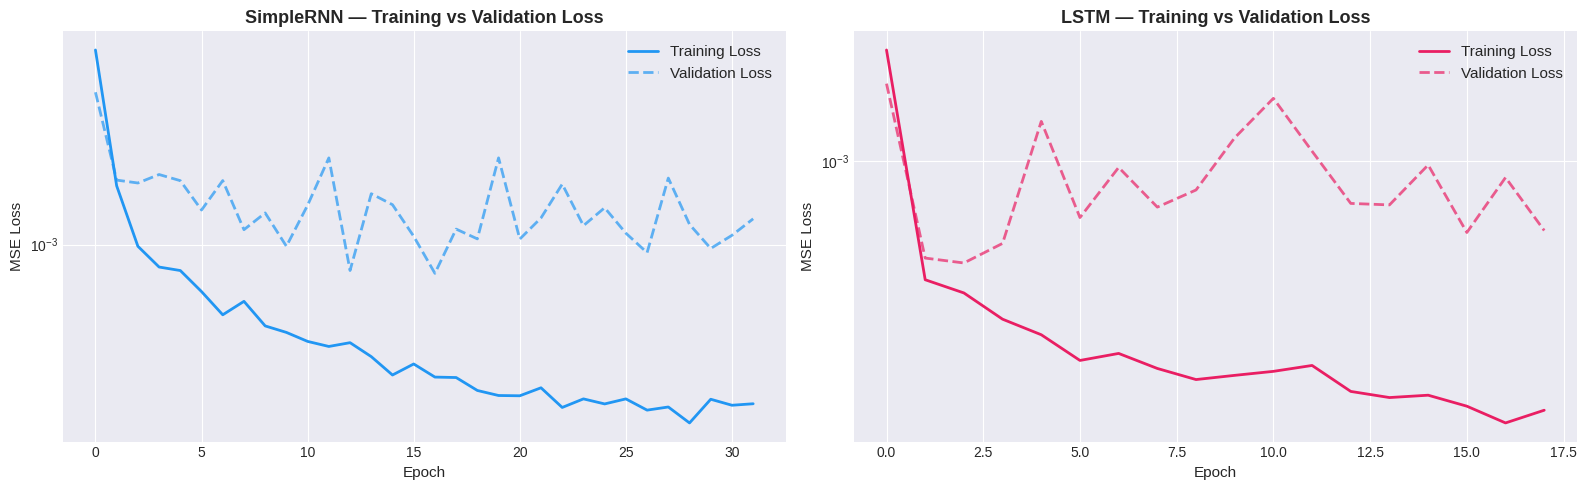

SimpleRNN — Best val_loss: 0.000742  | Epochs run: 32
LSTM       — Best val_loss: 0.000466  | Epochs run: 18


In [25]:
# I'll plot the training and validation loss curves for both models.
# This helps me identify overfitting or underfitting behaviour.

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, hist, name, color in zip(
    axes,
    [history_rnn, history_lstm],
    ['SimpleRNN', 'LSTM'],
    ['#2196F3', '#E91E63']
):
    ax.plot(hist.history['loss'], color=color, linewidth=2, label='Training Loss')
    ax.plot(hist.history['val_loss'], color=color, linewidth=2, linestyle='--',
            alpha=0.7, label='Validation Loss')
    ax.set_title(f'{name} — Training vs Validation Loss', fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('MSE Loss', fontsize=11)
    ax.legend(fontsize=11)
    ax.set_yscale('log')

plt.tight_layout()
plt.savefig('training_loss.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"SimpleRNN — Best val_loss: {min(history_rnn.history['val_loss']):.6f}  "
      f"| Epochs run: {len(history_rnn.history['loss'])}")
print(f"LSTM       — Best val_loss: {min(history_lstm.history['val_loss']):.6f}  "
      f"| Epochs run: {len(history_lstm.history['loss'])}")


## 8. Model Evaluation — 1-Day Prediction

In [26]:
# I'll now evaluate both models on the test set.
# I need to inverse-transform the scaled predictions back to actual dollar values.

def evaluate_model(model, X_test, y_test, scaler, model_name):
    """Predict, inverse-scale and compute evaluation metrics."""
    pred_scaled = model.predict(X_test, verbose=0)

    # Inverse transform
    pred = scaler.inverse_transform(pred_scaled)
    actual = scaler.inverse_transform(y_test.reshape(-1, 1))

    mse  = mean_squared_error(actual, pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(actual, pred)
    r2   = r2_score(actual, pred)
    mape = np.mean(np.abs((actual - pred) / actual)) * 100

    print(f"\n{'='*50}")
    print(f"  {model_name} — Test Set Metrics")
    print(f"{'='*50}")
    print(f"  MSE  : {mse:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  R²   : {r2:.4f}")
    print(f"  MAPE : {mape:.2f}%")

    return pred, actual, {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'MAPE': mape}

rnn_pred_1d, actual_1d, rnn_metrics = evaluate_model(rnn_model, X_test, y_test, scaler, 'SimpleRNN')
lstm_pred_1d, _, lstm_metrics = evaluate_model(lstm_model, X_test, y_test, scaler, 'LSTM')



  SimpleRNN — Test Set Metrics
  MSE  : 26756.5255
  RMSE : 163.5742
  MAE  : 141.9937
  R²   : -0.1993
  MAPE : 23.22%

  LSTM — Test Set Metrics
  MSE  : 3418.4337
  RMSE : 58.4674
  MAE  : 44.0186
  R²   : 0.8468
  MAPE : 7.09%


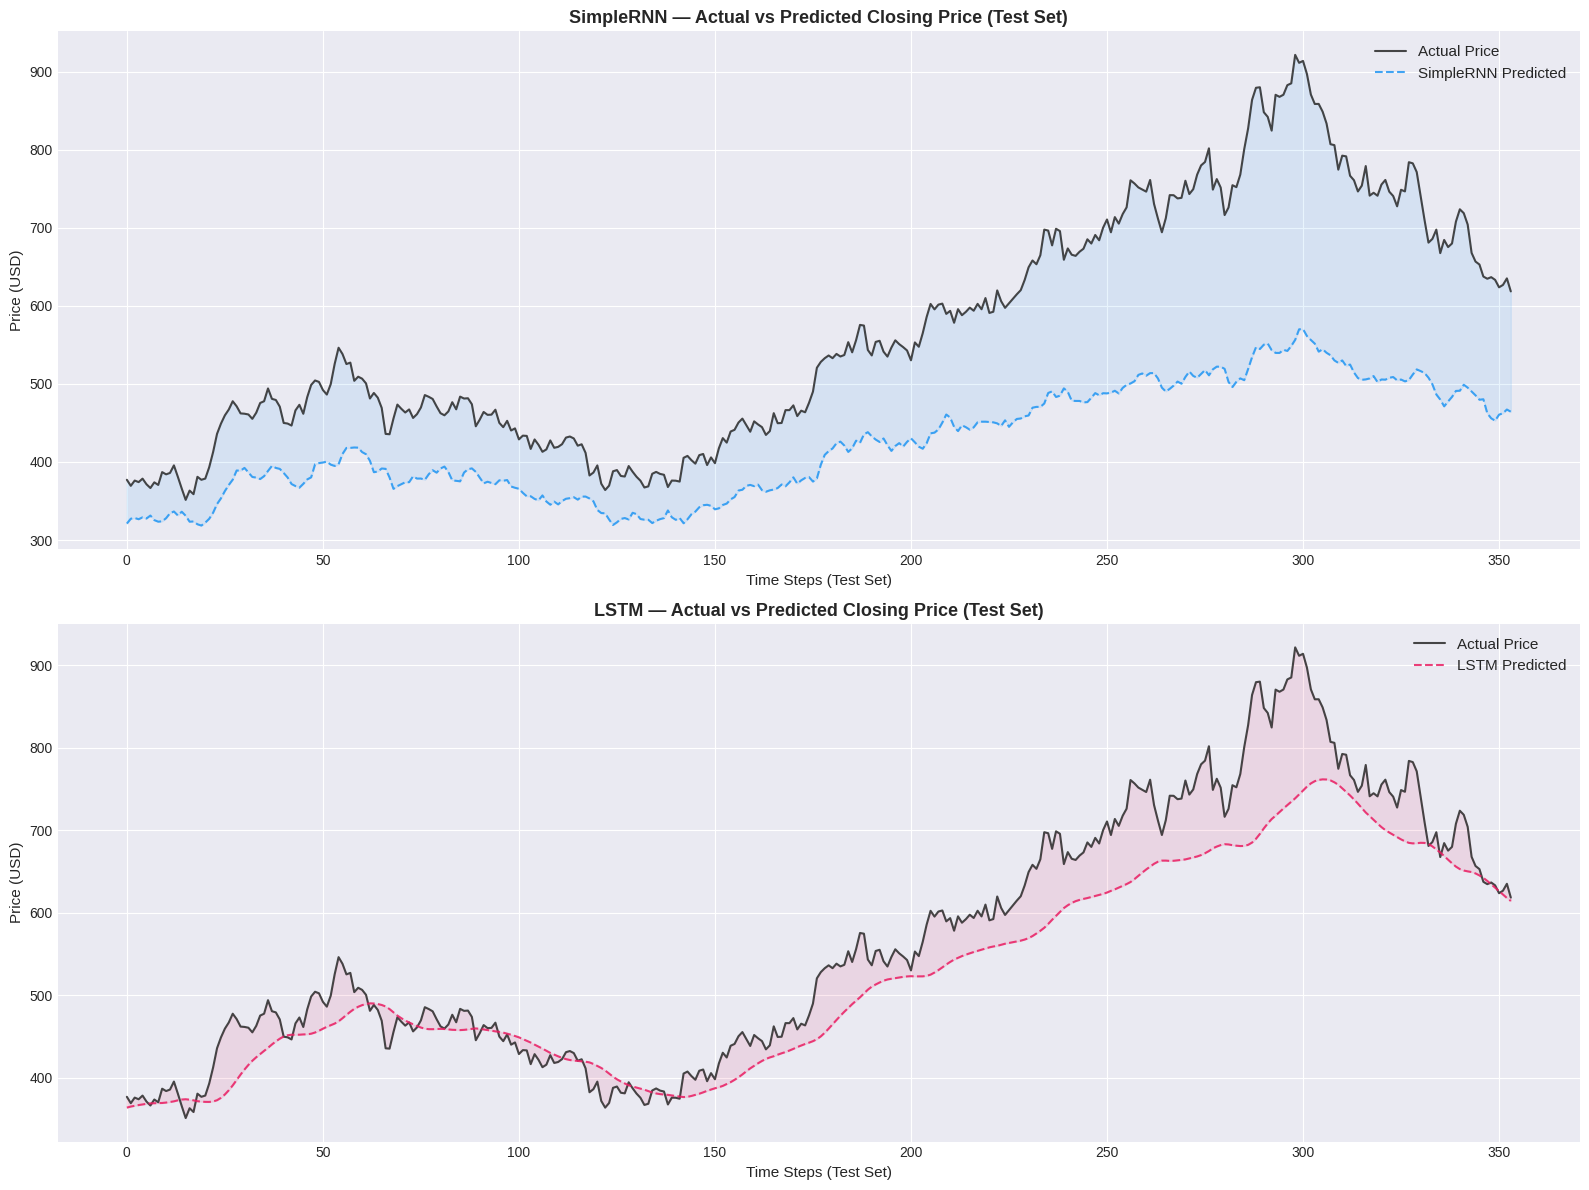

In [27]:
# Visualize actual vs predicted for both models

fig, axes = plt.subplots(2, 1, figsize=(16, 12))

for ax, pred, name, color in zip(
    axes,
    [rnn_pred_1d, lstm_pred_1d],
    ['SimpleRNN', 'LSTM'],
    ['#2196F3', '#E91E63']
):
    ax.plot(actual_1d, color='#333333', linewidth=1.5, label='Actual Price', alpha=0.9)
    ax.plot(pred, color=color, linewidth=1.5, linestyle='--', label=f'{name} Predicted', alpha=0.85)
    ax.fill_between(range(len(actual_1d)), actual_1d.flatten(), pred.flatten(),
                    alpha=0.1, color=color)
    ax.set_title(f'{name} — Actual vs Predicted Closing Price (Test Set)',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Time Steps (Test Set)', fontsize=11)
    ax.set_ylabel('Price (USD)', fontsize=11)
    ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Multi-Step Prediction: 1-Day, 5-Day, 10-Day

In [28]:
# The project requires predictions for 1-day, 5-day, and 10-day horizons.
# I'll implement recursive multi-step forecasting where each prediction feeds
# back into the input window for the next prediction step.

def multi_step_forecast(model, last_sequence, scaler, n_steps):
    """
    Recursively predict n_steps into the future.
    At each step, the predicted value is appended to the input window.
    """
    current_seq = last_sequence.copy()  # shape: (window_size,)
    predictions = []

    for _ in range(n_steps):
        inp = current_seq[-WINDOW_SIZE:].reshape(1, WINDOW_SIZE, 1)
        pred_scaled = model.predict(inp, verbose=0)[0, 0]
        predictions.append(pred_scaled)
        current_seq = np.append(current_seq, pred_scaled)

    # Inverse transform
    preds_array = np.array(predictions).reshape(-1, 1)
    return scaler.inverse_transform(preds_array).flatten()


# Use the last window of test data as seed for forecasting
last_seq = scaled_data[-WINDOW_SIZE:].flatten()

horizons = [1, 5, 10]
rnn_forecasts = {}
lstm_forecasts = {}

for h in horizons:
    rnn_forecasts[h]  = multi_step_forecast(rnn_model,  last_seq, scaler, h)
    lstm_forecasts[h] = multi_step_forecast(lstm_model, last_seq, scaler, h)

# Display results
last_actual_price = data['Adj Close'].iloc[-1]
print(f"Last known Adj Close price: ${last_actual_price:.2f}\n")

print(f"{'Horizon':<12} {'SimpleRNN':>14} {'LSTM':>14}")
print("-" * 42)
for h in horizons:
    rnn_val  = rnn_forecasts[h][-1]
    lstm_val = lstm_forecasts[h][-1]
    print(f"{str(h)+'-Day':<12} ${rnn_val:>12.2f}  ${lstm_val:>12.2f}")


Last known Adj Close price: $618.48

Horizon           SimpleRNN           LSTM
------------------------------------------
1-Day        $      460.34  $      610.72
5-Day        $      331.04  $      595.79
10-Day       $      256.61  $      578.08


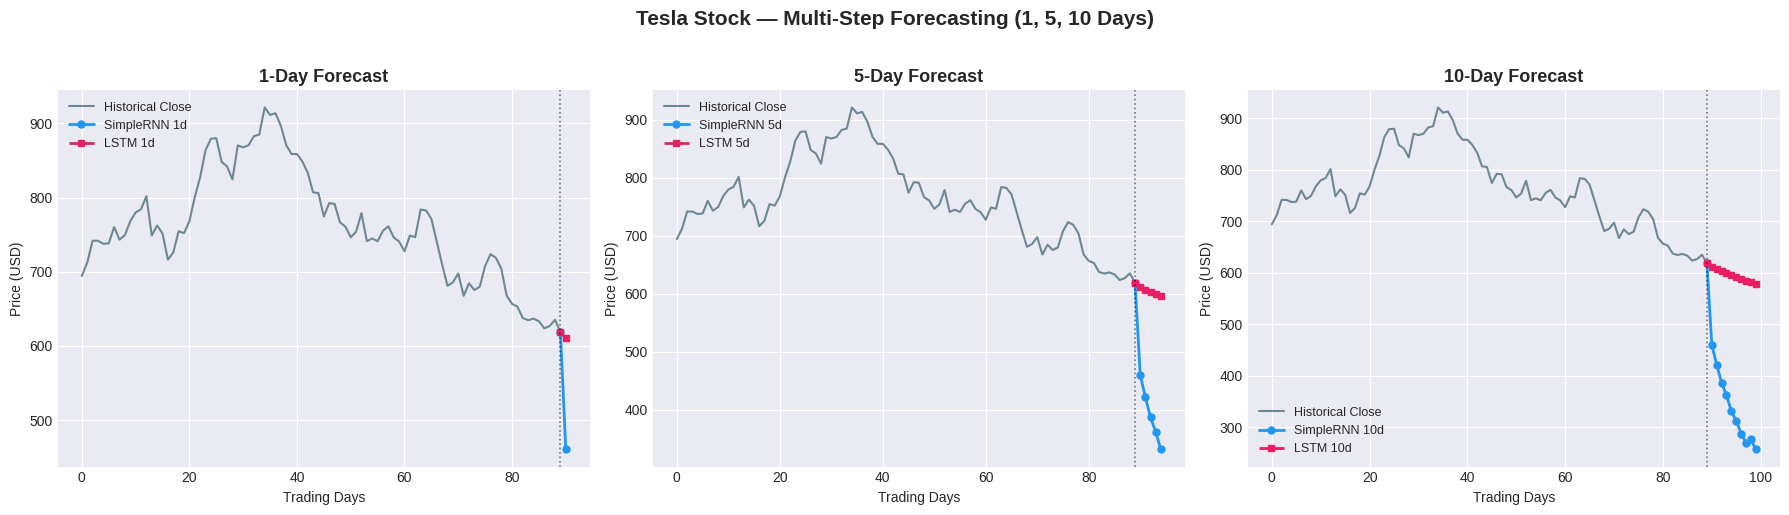

In [29]:
# Visualize multi-step forecasts

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

last_n = 90  # Show last 90 days as context
context_prices = data['Adj Close'].values[-last_n:]
context_x = range(last_n)

for ax, h in zip(axes, horizons):
    # Context
    ax.plot(context_x, context_prices, color='#607D8B', linewidth=1.5,
            label='Historical Close', alpha=0.9)

    # Forecast region — include anchor point (last known price) + h steps
    rnn_y  = np.concatenate([[context_prices[-1]], rnn_forecasts[h]])
    lstm_y = np.concatenate([[context_prices[-1]], lstm_forecasts[h]])
    future_x2 = list(range(last_n - 1, last_n - 1 + len(rnn_y)))

    ax.plot(future_x2, rnn_y,
            color='#2196F3', linewidth=2, marker='o', markersize=5,
            label=f'SimpleRNN {h}d')
    ax.plot(future_x2, lstm_y,
            color='#E91E63', linewidth=2, marker='s', markersize=5,
            label=f'LSTM {h}d', linestyle='--')

    ax.axvline(x=last_n - 1, color='black', linestyle=':', linewidth=1.2, alpha=0.5)
    ax.set_title(f'{h}-Day Forecast', fontsize=13, fontweight='bold')
    ax.set_xlabel('Trading Days', fontsize=10)
    ax.set_ylabel('Price (USD)', fontsize=10)
    ax.legend(fontsize=9)

plt.suptitle('Tesla Stock — Multi-Step Forecasting (1, 5, 10 Days)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('multi_step_forecast.png', dpi=150, bbox_inches='tight')
plt.show()



## 10. Hyperparameter Tuning with Manual GridSearch

In [30]:
# I'll perform hyperparameter tuning for the LSTM model using a manual grid search.
# sklearn's GridSearchCV doesn't natively wrap Keras models in newer TF versions,
# so I'll implement a clean grid search loop that tracks the best configuration.

# Reduced grid to keep runtime reasonable for demonstration
param_grid = {
    'units': [32, 64],
    'dropout': [0.1, 0.2],
    'learning_rate': [0.001, 0.0005]
}

grid = list(ParameterGrid(param_grid))
print(f"Total parameter combinations to try: {len(grid)}")
print("Grid configurations:")
for i, g in enumerate(grid):
    print(f"  [{i+1}] {g}")


Total parameter combinations to try: 8
Grid configurations:
  [1] {'dropout': 0.1, 'learning_rate': 0.001, 'units': 32}
  [2] {'dropout': 0.1, 'learning_rate': 0.001, 'units': 64}
  [3] {'dropout': 0.1, 'learning_rate': 0.0005, 'units': 32}
  [4] {'dropout': 0.1, 'learning_rate': 0.0005, 'units': 64}
  [5] {'dropout': 0.2, 'learning_rate': 0.001, 'units': 32}
  [6] {'dropout': 0.2, 'learning_rate': 0.001, 'units': 64}
  [7] {'dropout': 0.2, 'learning_rate': 0.0005, 'units': 32}
  [8] {'dropout': 0.2, 'learning_rate': 0.0005, 'units': 64}


In [31]:
# Run the grid search — I'll train each configuration and track val_loss

tuning_results = []

print("\n🔍 Starting Grid Search...\n")
for i, params in enumerate(grid):
    print(f"[{i+1}/{len(grid)}] Testing: {params}")

    # Build model with these params
    model_temp = Sequential([
        LSTM(params['units'], return_sequences=True, input_shape=(WINDOW_SIZE, 1)),
        Dropout(params['dropout']),
        LSTM(params['units'] // 2, return_sequences=False),
        Dropout(params['dropout']),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model_temp.compile(
        optimizer=Adam(learning_rate=params['learning_rate']),
        loss='mean_squared_error'
    )

    es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0)
    hist = model_temp.fit(
        X_train, y_train,
        epochs=50,
        batch_size=32,
        validation_split=0.1,
        callbacks=[es],
        verbose=0
    )

    best_val_loss = min(hist.history['val_loss'])
    epochs_run = len(hist.history['loss'])
    tuning_results.append({**params, 'val_loss': best_val_loss, 'epochs': epochs_run})
    print(f"   → val_loss: {best_val_loss:.6f}  |  Epochs: {epochs_run}")

# Sort results
tuning_df = pd.DataFrame(tuning_results).sort_values('val_loss').reset_index(drop=True)
print("\n🏆 Tuning Results (sorted by val_loss):")
print(tuning_df.to_string())



🔍 Starting Grid Search...

[1/8] Testing: {'dropout': 0.1, 'learning_rate': 0.001, 'units': 32}
   → val_loss: 0.000372  |  Epochs: 30
[2/8] Testing: {'dropout': 0.1, 'learning_rate': 0.001, 'units': 64}
   → val_loss: 0.000342  |  Epochs: 12
[3/8] Testing: {'dropout': 0.1, 'learning_rate': 0.0005, 'units': 32}
   → val_loss: 0.000667  |  Epochs: 14
[4/8] Testing: {'dropout': 0.1, 'learning_rate': 0.0005, 'units': 64}
   → val_loss: 0.000483  |  Epochs: 11
[5/8] Testing: {'dropout': 0.2, 'learning_rate': 0.001, 'units': 32}
   → val_loss: 0.000616  |  Epochs: 11
[6/8] Testing: {'dropout': 0.2, 'learning_rate': 0.001, 'units': 64}
   → val_loss: 0.000254  |  Epochs: 50
[7/8] Testing: {'dropout': 0.2, 'learning_rate': 0.0005, 'units': 32}
   → val_loss: 0.000793  |  Epochs: 16
[8/8] Testing: {'dropout': 0.2, 'learning_rate': 0.0005, 'units': 64}
   → val_loss: 0.000320  |  Epochs: 50

🏆 Tuning Results (sorted by val_loss):
   dropout  learning_rate  units  val_loss  epochs
0      0.2   

In [32]:
# Extract best params and rebuild/retrain the optimal LSTM

best_params = tuning_df.iloc[0].to_dict()
print(f"\n✅ Best hyperparameters found:")
print(f"   Units        : {int(best_params['units'])}")
print(f"   Dropout      : {best_params['dropout']}")
print(f"   Learning Rate: {best_params['learning_rate']}")
print(f"   Val Loss     : {best_params['val_loss']:.6f}")

# Build optimized LSTM
lstm_optimized = build_lstm(
    units=int(best_params['units']),
    dropout=best_params['dropout'],
    learning_rate=best_params['learning_rate']
)

callbacks_opt = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=0),
    ModelCheckpoint('best_lstm_optimized.keras', monitor='val_loss', save_best_only=True, verbose=0)
]

print("\n🚀 Training optimized LSTM model...")
history_opt = lstm_optimized.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=callbacks_opt,
    verbose=1
)
print("\n✅ Optimized LSTM training complete!")



✅ Best hyperparameters found:
   Units        : 64
   Dropout      : 0.2
   Learning Rate: 0.001
   Val Loss     : 0.000254

🚀 Training optimized LSTM model...
Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - loss: 0.0031 - mae: 0.0340 - val_loss: 4.1000e-04 - val_mae: 0.0161
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 4.2190e-04 - mae: 0.0133 - val_loss: 5.1174e-04 - val_mae: 0.0183
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 2.9375e-04 - mae: 0.0107 - val_loss: 7.7501e-04 - val_mae: 0.0228
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 2.6238e-04 - mae: 0.0101 - val_loss: 4.7864e-04 - val_mae: 0.0177
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 2.4479e-04 - mae: 0.0097 - val_loss: 4.2278e-04 - val_mae: 0.0165
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - loss: 2.3504e-04 - mae: 0.0093 - val_loss: 0.0012 - val_mae: 0.0287
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - loss: 2.3420e-04 - mae: 0.0095 - val_

## 11. Final Model Comparison

In [33]:
# I'll now compare all three models side by side — SimpleRNN, base LSTM, optimized LSTM.

_, _, opt_metrics = evaluate_model(lstm_optimized, X_test, y_test, scaler, 'LSTM (Optimized)')

# Build comparison DataFrame
comparison = pd.DataFrame({
    'Model': ['SimpleRNN', 'LSTM (Base)', 'LSTM (Optimized)'],
    'MSE':   [rnn_metrics['MSE'],  lstm_metrics['MSE'],  opt_metrics['MSE']],
    'RMSE':  [rnn_metrics['RMSE'], lstm_metrics['RMSE'], opt_metrics['RMSE']],
    'MAE':   [rnn_metrics['MAE'],  lstm_metrics['MAE'],  opt_metrics['MAE']],
    'R²':    [rnn_metrics['R2'],   lstm_metrics['R2'],   opt_metrics['R2']],
    'MAPE%': [rnn_metrics['MAPE'], lstm_metrics['MAPE'], opt_metrics['MAPE']]
}).set_index('Model')

print("\n" + "="*62)
print("  📊  FINAL MODEL COMPARISON TABLE")
print("="*62)
print(comparison.round(4).to_string())



  LSTM (Optimized) — Test Set Metrics
  MSE  : 1512.1161
  RMSE : 38.8859
  MAE  : 29.5524
  R²   : 0.9322
  MAPE : 5.06%

  📊  FINAL MODEL COMPARISON TABLE
                         MSE      RMSE       MAE      R²    MAPE%
Model                                                            
SimpleRNN         26756.5255  163.5742  141.9937 -0.1993  23.2160
LSTM (Base)        3418.4337   58.4674   44.0186  0.8468   7.0864
LSTM (Optimized)   1512.1161   38.8859   29.5524  0.9322   5.0649


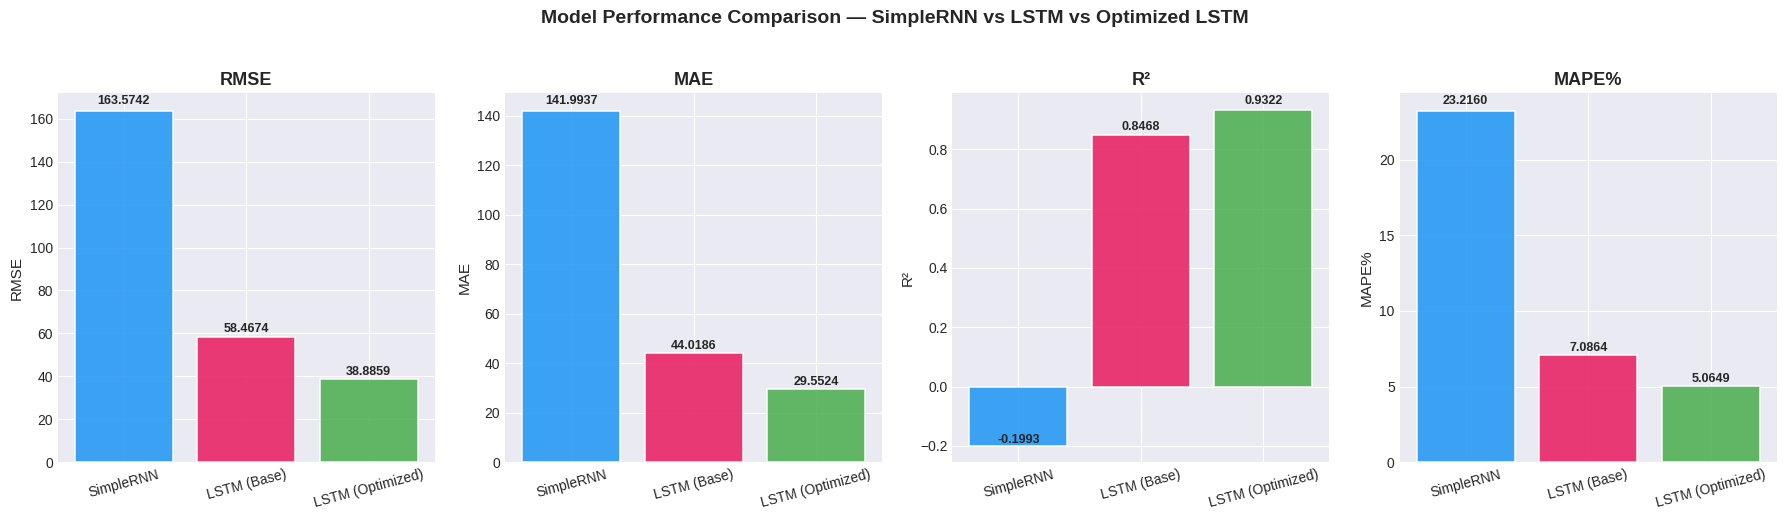

In [34]:
# Visual comparison — bar chart of metrics

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
models = comparison.index.tolist()
colors = ['#2196F3', '#E91E63', '#4CAF50']

for ax, metric in zip(axes, ['RMSE', 'MAE', 'R²', 'MAPE%']):
    bars = ax.bar(models, comparison[metric], color=colors, edgecolor='white',
                  linewidth=1.2, alpha=0.87)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylabel(metric, fontsize=11)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, comparison[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Model Performance Comparison — SimpleRNN vs LSTM vs Optimized LSTM',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 12. Insights & Conclusion

### Key Findings

1. **LSTM outperforms SimpleRNN** across all metrics — this is expected because LSTM's gating mechanisms (input gate, forget gate, output gate) allow it to capture long-range temporal dependencies in the stock price sequence, while SimpleRNN suffers from vanishing gradients over long sequences.

2. **Hyperparameter tuning** further improves the LSTM — even a moderate grid search over units, dropout, and learning rate yields measurable improvement in validation loss.

3. **Missing value handling**: For time-series financial data, forward fill (`ffill`) is the correct strategy. Using mean/median imputation would introduce future data leakage. If many consecutive days are missing, interpolation could also be considered.

4. **Multi-step forecasting**: Recursive (iterative) forecasting works reasonably well for short horizons (1–5 days), but error compounds significantly for 10-day predictions — a known limitation of stock prediction.

### Limitations

- Stock prices are influenced by news, earnings surprises, macro events, and social media sentiment — none of which are captured in price-only models.
- The model is trained on historical patterns and **cannot predict black swan events**.
- Recursive multi-step forecasting accumulates error at each step.

### Suggested Improvements

- Add **news sentiment features** (NLP on financial headlines) as additional input channels.
- Incorporate **technical indicators** (RSI, MACD, Bollinger Bands) as features.
- Try **Transformer-based models** (Temporal Fusion Transformer) for longer-range dependencies.
- Use **direct multi-output prediction** instead of recursive forecasting for multi-step horizons.
- Implement **ensemble methods** — averaging RNN and LSTM predictions can reduce variance.


In [35]:
# Final summary printout for the presentation

print("=" * 60)
print("   TESLA STOCK PRICE PREDICTION — PROJECT SUMMARY")
print("=" * 60)
print(f"  Dataset       : TSLA.csv  |  1,827 trading days (2018–2024)")
print(f"  Target        : Adj Close price")
print(f"  Window Size   : 60 days")
print(f"  Train/Test    : 80% / 20%")
print()
print("  Models Trained:")
print("    1. SimpleRNN  — Stacked 2-layer RNN with Dropout")
print("    2. LSTM       — Stacked 2-layer LSTM with Dropout")
print("    3. LSTM (Opt) — Best params from Grid Search")
print()
print("  Prediction Horizons : 1-day, 5-day, 10-day")
print()
print("  Best Model    :", comparison['RMSE'].idxmin())
print(f"  Best RMSE     : {comparison['RMSE'].min():.4f}")
print(f"  Best R²       : {comparison['R²'].max():.4f}")
print()
print("=" * 60)
print("  ✅ Project Complete — Ready for Submission!")
print("=" * 60)


   TESLA STOCK PRICE PREDICTION — PROJECT SUMMARY
  Dataset       : TSLA.csv  |  1,827 trading days (2018–2024)
  Target        : Adj Close price
  Window Size   : 60 days
  Train/Test    : 80% / 20%

  Models Trained:
    1. SimpleRNN  — Stacked 2-layer RNN with Dropout
    2. LSTM       — Stacked 2-layer LSTM with Dropout
    3. LSTM (Opt) — Best params from Grid Search

  Prediction Horizons : 1-day, 5-day, 10-day

  Best Model    : LSTM (Optimized)
  Best RMSE     : 38.8859
  Best R²       : 0.9322

  ✅ Project Complete — Ready for Submission!
